In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_ScipySp
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
# phic = (3 * beta)**(-0.5)
# M = phic / 2**0.5
Lambda = (1e-15)**0.25
nWaterfall = 1
psic = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5
beta = 1e4

def infPotFunc(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * ((1 - (psi / M)**2)**2 + 2 * (phi * psi / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * phi * (psi / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 * psi / M**2 * (1 - (psi / M)**2) + 4 * psi * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * (psi / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psi / M / M)**2 + 4 * (phi / phic / M)**2))

def infPotDeriv2Func_phipsi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (8 * phi * psi / (phic * M)**2))

def eta_psi(Phi):
    return infPotDeriv2Func_psi(Phi) / infPotFunc(Phi)

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psi]
infPotentialDeriv2Funcs = [[infPotDeriv2Func_phi, infPotDeriv2Func_phipsi], [infPotDeriv2Func_phipsi, infPotDeriv2Func_psi]]

nGrid = 1000

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phiLargeEtaMax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell) 
phiLargeEtaMin = phic - (phiLargeEtaMax - phic)

# 以下は1912.05399に準拠。下限はad hoc
phimax = phic + beta**(-1/3)
phimin = phic - beta**(-1/3)

In [4]:
psiLargeEtaMax = bisect(lambda psi: etaCl_psi([phiLargeEtaMax, psi]) - 0.1, 0.0001 * psic, 1000 * psic)
psiLargeEtaMin = -psiLargeEtaMax 

psimax = bisect(lambda psi: eta_psi([phic, psi]) - 1, 0, M)
psimin = -psimax

In [5]:
customGrid_phi = np.concatenate([phic - np.exp(np.linspace(np.log(phic - phimin), np.log(phic - phiLargeEtaMin), nGrid // 4, endpoint=False)),
                                 np.linspace(phiLargeEtaMin, phiLargeEtaMax, nGrid // 2),
                                 phic + np.exp(np.linspace(np.log(phiLargeEtaMax - phic), np.log(phimax - phic), nGrid // 4 + 1)[1:])])
customGrid_psi = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), nGrid // 4 + 1))[:-1],
                                 np.linspace(psiLargeEtaMin, psiLargeEtaMax, nGrid // 2),
                                 np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), nGrid // 4 + 1))[1:]])

In [6]:
phic

0.0011582420658256308

In [7]:
customGrid_phi

array([-4.52576463e-02, -4.29580683e-02, -4.07724181e-02, -3.86950513e-02,
       -3.67206034e-02, -3.48439753e-02, -3.30603208e-02, -3.13650338e-02,
       -2.97537362e-02, -2.82222670e-02, -2.67666712e-02, -2.53831898e-02,
       -2.40682502e-02, -2.28184564e-02, -2.16305811e-02, -2.05015566e-02,
       -1.94284672e-02, -1.84085418e-02, -1.74391465e-02, -1.65177778e-02,
       -1.56420565e-02, -1.48097208e-02, -1.40186216e-02, -1.32667156e-02,
       -1.25520613e-02, -1.18728130e-02, -1.12272167e-02, -1.06136051e-02,
       -1.00303936e-02, -9.47607606e-03, -8.94922104e-03, -8.44846794e-03,
       -7.97252361e-03, -7.52015895e-03, -7.09020575e-03, -6.68155367e-03,
       -6.29314741e-03, -5.92398392e-03, -5.57310987e-03, -5.23961913e-03,
       -4.92265050e-03, -4.62138541e-03, -4.33504587e-03, -4.06289242e-03,
       -3.80422225e-03, -3.55836735e-03, -3.32469281e-03, -3.10259519e-03,
       -2.89150093e-03, -2.69086490e-03, -2.50016895e-03, -2.31892064e-03,
       -2.14665190e-03, -

In [22]:
customGrid_psi

array([-1.93631193e-07, -1.88260458e-07, -1.83038691e-07, -1.77961759e-07,
       -1.73025646e-07, -1.68226446e-07, -1.63560361e-07, -1.59023699e-07,
       -1.54612870e-07, -1.50324383e-07, -1.46154846e-07, -1.42100960e-07,
       -1.38159515e-07, -1.34327395e-07, -1.30601565e-07, -1.26979079e-07,
       -1.23457069e-07, -1.20032749e-07, -1.16703409e-07, -1.13466414e-07,
       -1.10319204e-07, -1.07259288e-07, -1.04284245e-07, -1.01391720e-07,
       -9.85794252e-08, -9.58451346e-08, -9.31866848e-08, -9.06019723e-08,
       -8.80889517e-08, -8.56456346e-08, -8.32700877e-08, -8.09604311e-08,
       -7.87148373e-08, -7.65315294e-08, -7.44087797e-08, -7.23449086e-08,
       -7.03382829e-08, -6.83873149e-08, -6.64904607e-08, -6.46462195e-08,
       -6.28531318e-08, -6.11097789e-08, -5.94147813e-08, -5.77667976e-08,
       -5.61645240e-08, -5.46066926e-08, -5.30920706e-08, -5.16194595e-08,
       -5.01876942e-08, -4.87956416e-08, -4.74422003e-08, -4.61262993e-08,
       -4.48468974e-08, -

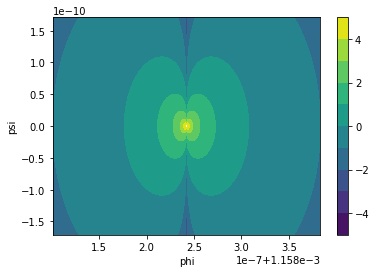

In [8]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

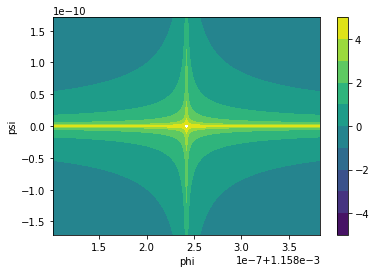

In [9]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

In [10]:
fpFinDiff_NeuDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psi_woEnd = customGrid_psi[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psi_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuDir, eigVecs_NeuDir = eigs(fpFinDiff_NeuDir, 10, sigma=0, which='LM')
eigVecsSort_NeuDir = eigVecs_NeuDir.T[np.argsort(np.abs(eigVals_NeuDir))]
eigValsSort_NeuDir = eigVals_NeuDir[np.argsort(np.abs(eigVals_NeuDir))]

In [11]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuDir)
np.set_printoptions()

  (0, 0)	4.981478115019142e+25
  (0, 1)	-0.021005302200905233
  (0, 998)	-1.708128205105405e-13
  (1, 0)	-0.022220903158950502
  (1, 1)	4.710151601449101e+25
  (1, 2)	-0.022853578200318022
  (1, 999)	-1.7080666374342545e-13
  (2, 1)	-0.023505549993266976
  (2, 2)	4.453583734297233e+25
  (2, 3)	-0.024174873715752818
  (2, 1000)	-1.7080084377931578e-13
  (3, 2)	-0.024864539711275477
  (3, 3)	4.210976078859348e+25
  (3, 4)	-0.0255726329846512
  (3, 1001)	-1.707953421935643e-13
  (4, 3)	-0.026302174557147586
  (4, 4)	3.981572931838864e+25
  (4, 5)	-0.02705128098653095
  (4, 1002)	-1.7079014156943443e-13
  (5, 4)	-0.02782300574716875
  (5, 5)	3.7646590839012903e+25
  (5, 6)	-0.028615498775755508
  (5, 1003)	-1.7078522544296485e-13
  (6, 5)	-0.029431847877828304
  (6, 6)	3.5595576940584884e+25
  :	:
  (995997, 995997)	1.9367158931670232e+22
  (995997, 995998)	-0.3866321352877419
  (995998, 995000)	-3.1225376182573814e-12
  (995998, 995997)	-0.3759081468455455
  (995998, 995998)	2.04859024371

In [12]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = eigs(fpFinDiff_DirDir, 10, sigma=0, which='LM')
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(np.abs(eigVals_DirDir))]
eigValsSort_DirDir = eigVals_DirDir[np.argsort(np.abs(eigVals_DirDir))]

In [13]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

  (0, 0)	4.981478115019142e+25
  (0, 1)	-0.021005302200905233
  (0, 998)	-1.708128205105405e-13
  (1, 0)	-0.022220903158950502
  (1, 1)	4.710151601449101e+25
  (1, 2)	-0.022853578200318022
  (1, 999)	-1.7080666374342545e-13
  (2, 1)	-0.023505549993266976
  (2, 2)	4.453583734297233e+25
  (2, 3)	-0.024174873715752818
  (2, 1000)	-1.7080084377931578e-13
  (3, 2)	-0.024864539711275477
  (3, 3)	4.210976078859348e+25
  (3, 4)	-0.0255726329846512
  (3, 1001)	-1.707953421935643e-13
  (4, 3)	-0.026302174557147586
  (4, 4)	3.981572931838864e+25
  (4, 5)	-0.02705128098653095
  (4, 1002)	-1.7079014156943443e-13
  (5, 4)	-0.02782300574716875
  (5, 5)	3.7646590839012903e+25
  (5, 6)	-0.028615498775755508
  (5, 1003)	-1.7078522544296485e-13
  (6, 5)	-0.029431847877828304
  (6, 6)	3.5595576940584884e+25
  :	:
  (995997, 995997)	1.9367158931670232e+22
  (995997, 995998)	-0.3866321352877419
  (995998, 995000)	-1.4937246542475616e-12
  (995998, 995997)	-0.3759081468455455
  (995998, 995998)	2.04859024371

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


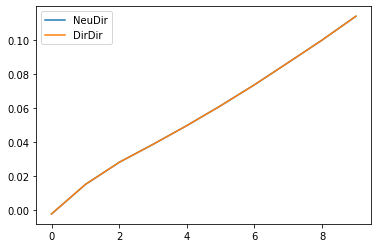

In [14]:
ax = plt.gca()
plt.plot(eigValsSort_NeuDir, label = "NeuDir")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

In [15]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuDir[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[-0.00241918+0.j  0.01492489+0.j  0.02798066+0.j  0.03858618+0.j
  0.0496309 +0.j  0.06134292+0.j  0.0737087 +0.j  0.08680741+0.j
  0.10004397+0.j  0.11409141+0.j]
[-0.00241918+0.j  0.01492489+0.j  0.02798066+0.j  0.03858618+0.j
  0.0496309 +0.j  0.06134292+0.j  0.0737087 +0.j  0.08680741+0.j
  0.10004397+0.j  0.11409141+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


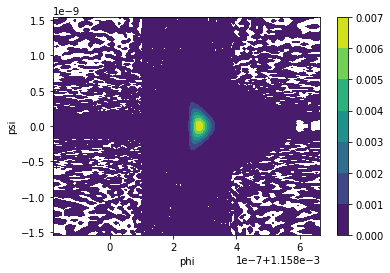

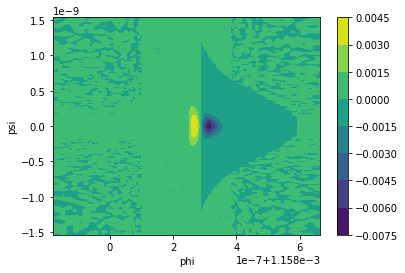

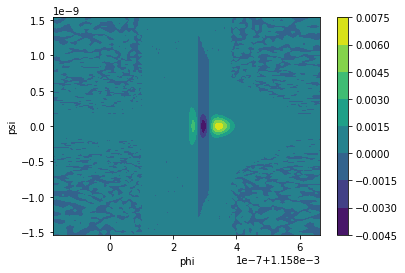

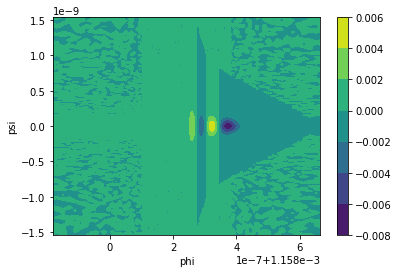

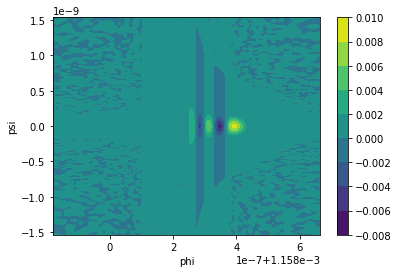

In [16]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psi_woEnd = customGrid_psi[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

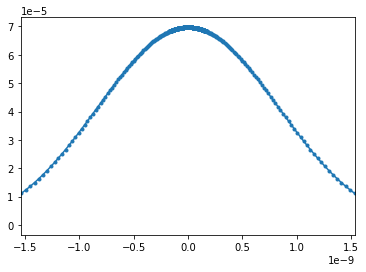

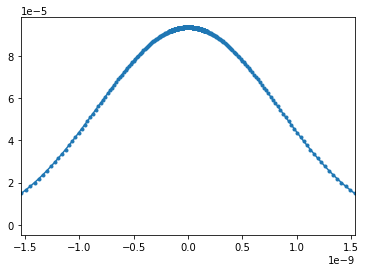

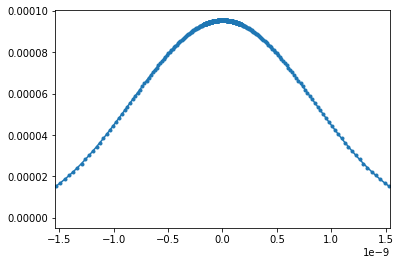

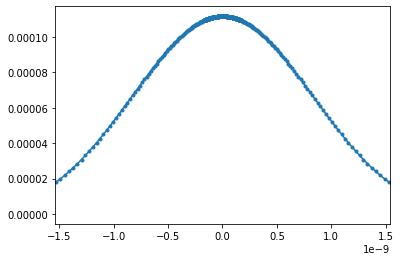

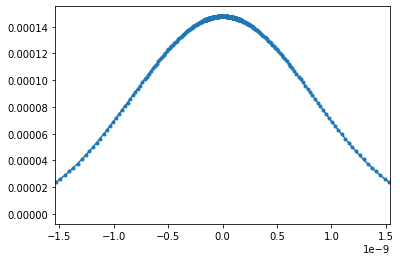

In [17]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[nGrid // 2,:], marker='.')
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

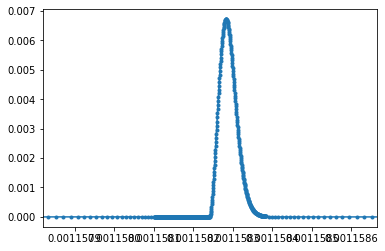

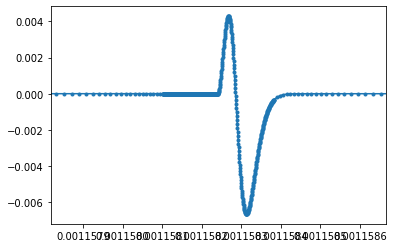

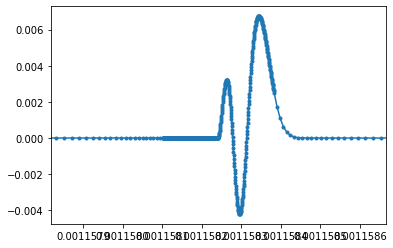

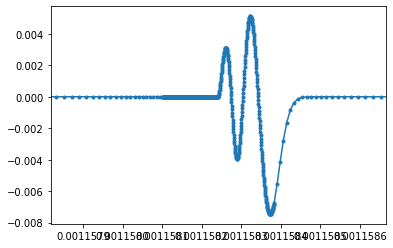

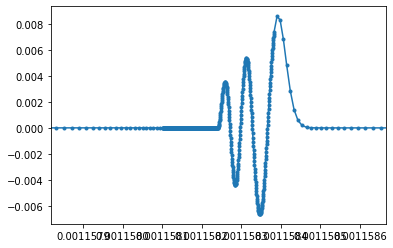

In [18]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    plt.show()

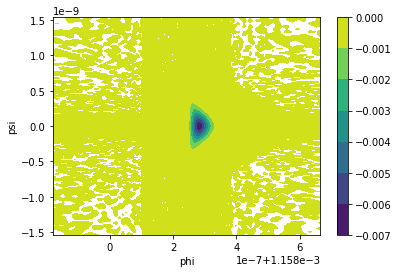

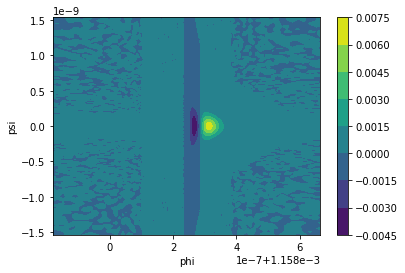

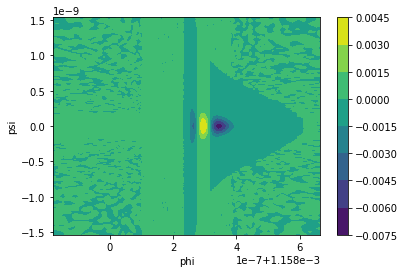

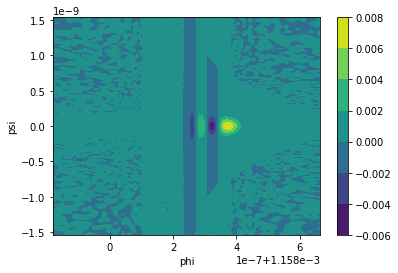

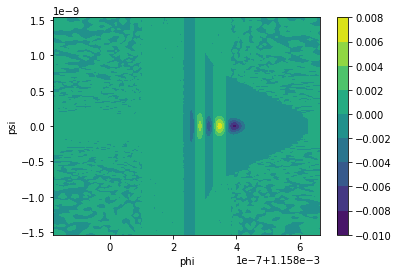

In [19]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

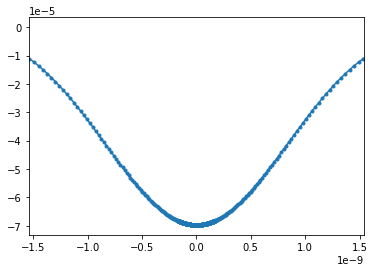

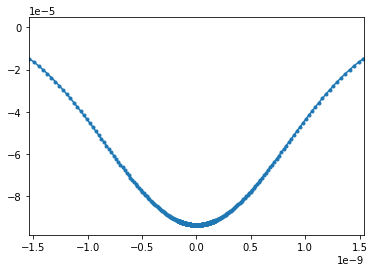

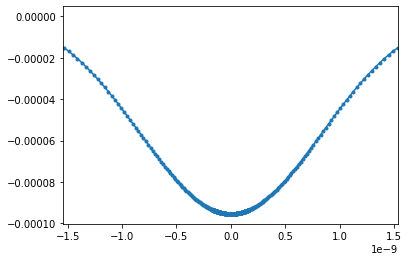

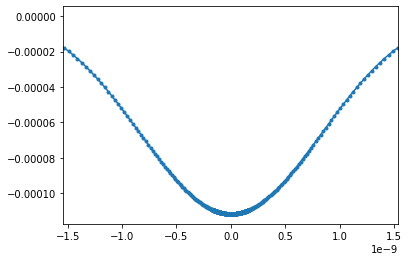

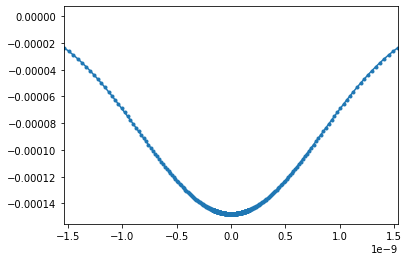

In [20]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[nGrid//2,:],marker=".")
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

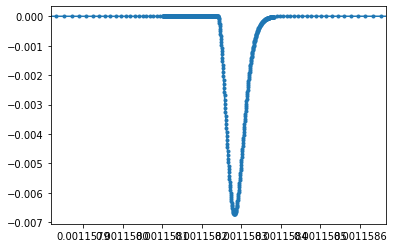

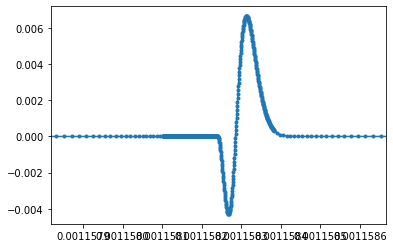

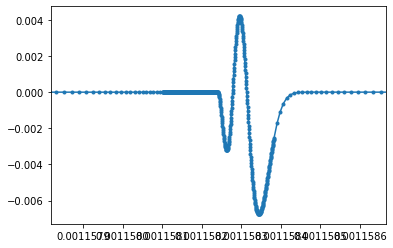

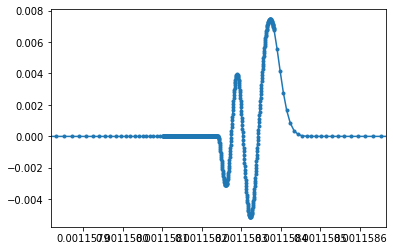

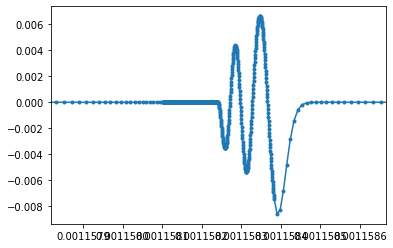

In [21]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([2 * phiLargeEtaMin - phiLargeEtaMax, 2 * phiLargeEtaMax - phiLargeEtaMin])
    plt.show()